In [1]:
%reload_ext autoreload
%autoreload 2

# Forecasting Module Demo
Пример использования Forecaster c dummy-моделями.

In [2]:
import pandas as pd
import numpy as np
from multi_item_forecaster import MultiItemForecaster
from utils.plot import plot_forecast

shop_sales = pd.read_csv(r"C:\Users\makanov.artem\Desktop\ВР\data\shop_sales_store1.csv", index_col=0)
shop_dates = pd.read_csv(r"C:\Users\makanov.artem\Desktop\ВР\data\shop_sales_dates_store1.csv", index_col=0)

df = shop_sales.merge(shop_dates, on="date_id", how="left")

num_exog_cols = [
    'month',
    'wday',
    'year',
    'CASHBACK'
]

cat_exog_cols = [
    'event_name_1',
    'event_type_1',
    'event_name_2',
    'event_type_2',
]
exog_cols = num_exog_cols + cat_exog_cols

df = df[['item_id', 'date', 'cnt'] + exog_cols]

for col in cat_exog_cols:
    df[col] = (~df[col].isna()).astype(np.int32)    

holiday_cols = [
    'event_name_1',
    'event_name_2',
    'CASHBACK'
]

In [5]:
horizon = 14
last_k_days = 28

In [12]:


multi_fc = MultiItemForecaster(model_name="sarimax")
multi_fc.fit(df, exog_cols=exog_cols, order=(2,0,1), seasonal_order=(0,0,0,0))


In [15]:
df.item_id.unique().tolist()

['STORE_1_046',
 'STORE_1_033',
 'STORE_1_043',
 'STORE_1_090',
 'STORE_1_099',
 'STORE_1_131',
 'STORE_1_252',
 'STORE_1_295',
 'STORE_1_304',
 'STORE_1_491',
 'STORE_1_542',
 'STORE_1_555',
 'STORE_1_586',
 'STORE_1_587',
 'STORE_1_714']

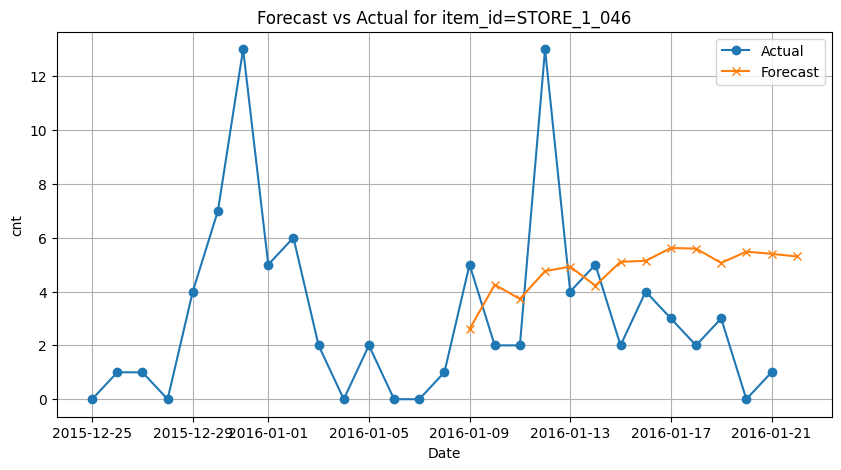

In [20]:

forecasts = multi_fc.predict(horizon=horizon, test=df, exog_cols=exog_cols)

plot_forecast(df, forecasts, item_id='STORE_1_046', horizon=horizon, last_k_days=last_k_days)


In [21]:
metrics_per_item, metrics_agg = multi_fc.evaluate(df, horizon=horizon, exog_cols=exog_cols)
metrics_agg

ValueError: The truth value of a DataFrame is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().